# Supermarket Sales Analysis

### Author: Arvin Kelly M. Butiong
### Objective: Sales Performance & Customer Behavior Analysis
    This analysis evaluates supermarket transaction data to identify revenue drivers, customer behavior patterns, and operational insights that support data-driven business decisions.

## 1. Business Context
    The dataset contains 1,000 transaction-level records across three cities and branches. Each row represents a single customer purchase including product category, pricing, payment method, and rating.
The goals of this analysis are to:


- Identify key revenue drivers  
- Analyze customer purchasing behavior  
- Examine time-based sales patterns  
- Generate actionable business recommendations  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")
pd.set_option("display.max_columns", None)

## 2. Load Dataset

In [2]:
df = pd.read_csv("SuperMarket Analysis.csv")
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


## 3. Dataset Overview

### 3.1 Dataset Dimensions

In [3]:
df.shape

(1000, 17)

### 3.2 Data Types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

### 3.3 Summary Statistics

In [5]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


### 3.4 Missing Values

In [6]:
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

### Observations:
- The dataset contains 1,000 transactions and 17 features.
- No missing values are present.
- Gross margin percentage is constant, indicating a fixed pricing structure.
- Revenue and gross income are proportionally related.

## 4. Data Cleaning & Feature Engineering

### 4.1 Standardize Column Names

In [7]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("%", "percent")
)
df.columns

Index(['invoice_id', 'branch', 'city', 'customer_type', 'gender',
       'product_line', 'unit_price', 'quantity', 'tax_5percent', 'sales',
       'date', 'time', 'payment', 'cogs', 'gross_margin_percentage',
       'gross_income', 'rating'],
      dtype='object')

### 4.2 Convert Date and Create Time Features

In [8]:
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.month_name()
df["day_name"] = df["date"].dt.day_name()
df["hour"] = pd.to_datetime(df["time"], format="%I:%M:%S %p").dt.hour

### 4.3 Validate Revenue Calculation

In [9]:
difference = df["sales"] - (df["cogs"] + df["tax_5percent"])
difference.describe()

count    1.000000e+03
mean    -1.199041e-15
std      3.197311e-14
min     -1.136868e-13
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.136868e-13
dtype: float64

### Observation:
    Minor discrepancies are due to floating-point precision and do not materially impact financial totals.

## 5. Key Performance Indicators (KPIs)


In [10]:
total_revenue = df["sales"].sum()
avg_order_value = df["sales"].mean()
total_transactions = df["invoice_id"].nunique()
avg_rating = df["rating"].mean()

print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Average Order Value: {avg_order_value:,.2f}")
print(f"Total Transactions: {total_transactions}")
print(f"Average Rating: {avg_rating:.2f}")

Total Revenue: 322,966.75
Average Order Value: 322.97
Total Transactions: 1000
Average Rating: 6.97


### Insight:
    The supermarket generated over 322,000 in revenue across 1,000 transactions, with an average order value of approximately 323 per transaction.

## 6. Revenue Analysis

### 6.1 Revenue by City

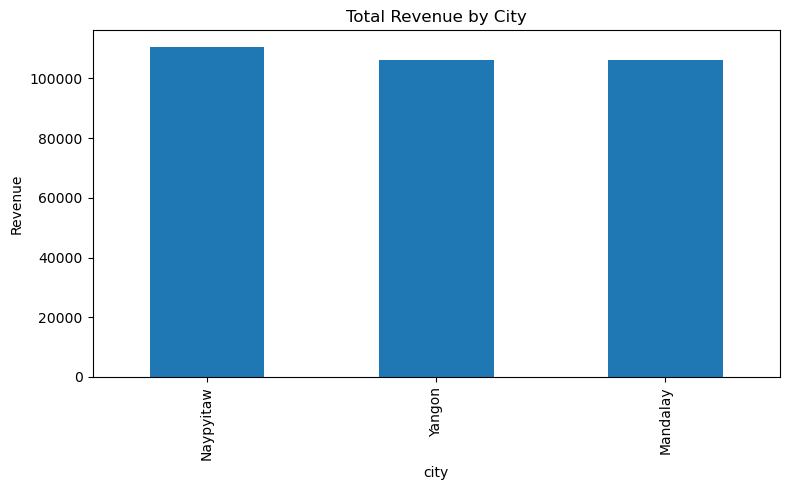

city
Naypyitaw    110568.7065
Yangon       106200.3705
Mandalay     106197.6720
Name: sales, dtype: float64

In [11]:
revenue_by_city = (
    df.groupby("city")["sales"].sum().sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
revenue_by_city.plot(kind="bar")
plt.title("Total Revenue by City")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

revenue_by_city

In [12]:
(revenue_by_city / revenue_by_city.sum() * 100).round(2)

city
Naypyitaw    34.24
Yangon       32.88
Mandalay     32.88
Name: sales, dtype: float64

#### Insight: 
    Naypyitaw generates the highest revenue, contributing approximately 34% of total sales.

### 6.2 Revenue by Product Line

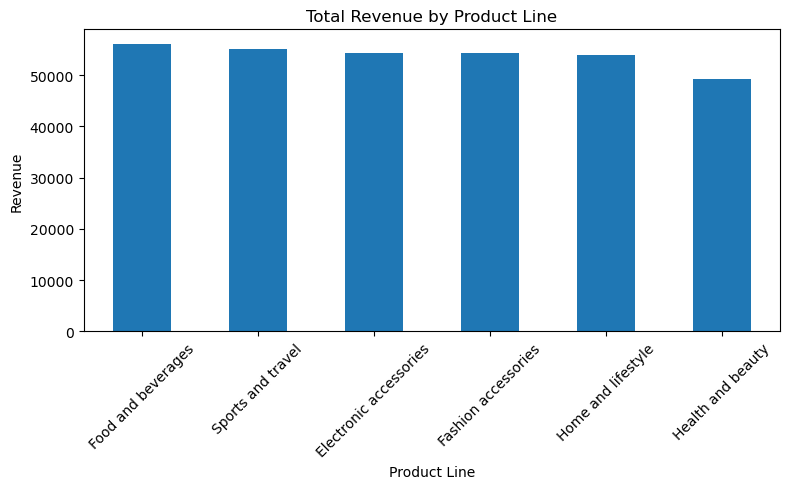

product_line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: sales, dtype: float64

In [13]:
revenue_by_product = df.groupby("product_line")["sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
revenue_by_product.plot(kind="bar")
plt.title("Total Revenue by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

revenue_by_product

### Insight:
    Food and Beverages generates 56,144 in revenue, the highest among all product lines, accounting for approximately 17% of total sales. Health and Beauty contributes the lowest revenue, suggesting potential underperformance relative to other categories.

### 6.3 Revenue Distribution

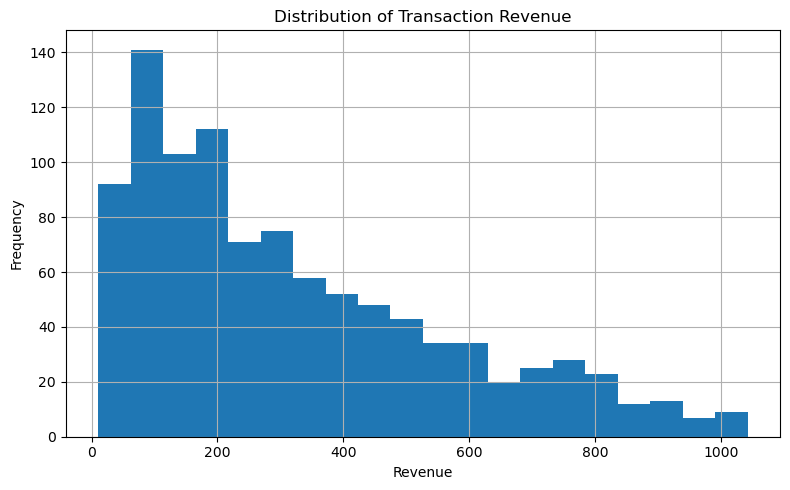

In [14]:
plt.figure(figsize=(8,5))
df["sales"].hist(bins=20)
plt.title("Distribution of Transaction Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Observation:

Revenue distribution is right-skewed, with most transactions clustered between 100 and 500.

## 7. Time-Based Sales Analysis

### 7.1 Daily Revenue Trend

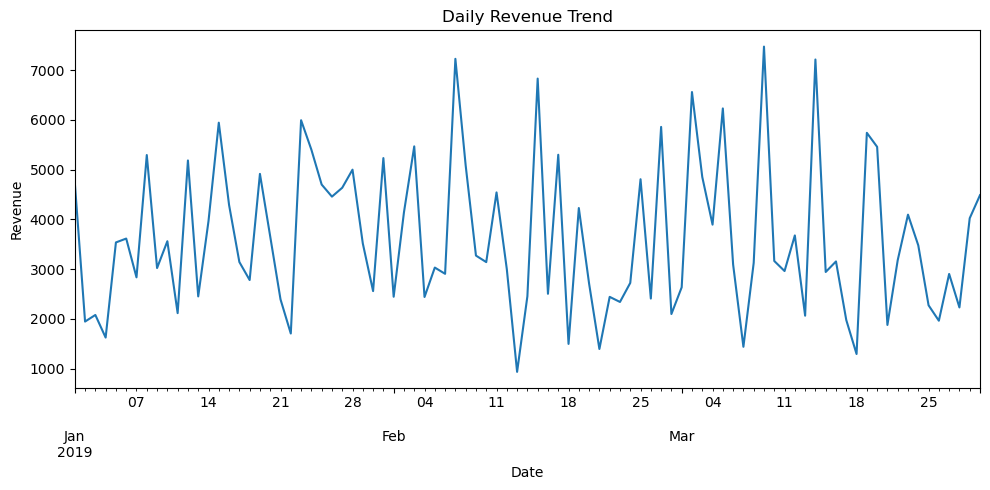

In [15]:
daily_sales = df.groupby("date")["sales"].sum()

plt.figure(figsize=(10,5))
daily_sales.plot()
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

### Observation:
    No consistent upward or downward trend is observed, indicating stable but non-growing short-term performance across the 3-month period.

### 7.2 Average Sales by Hour

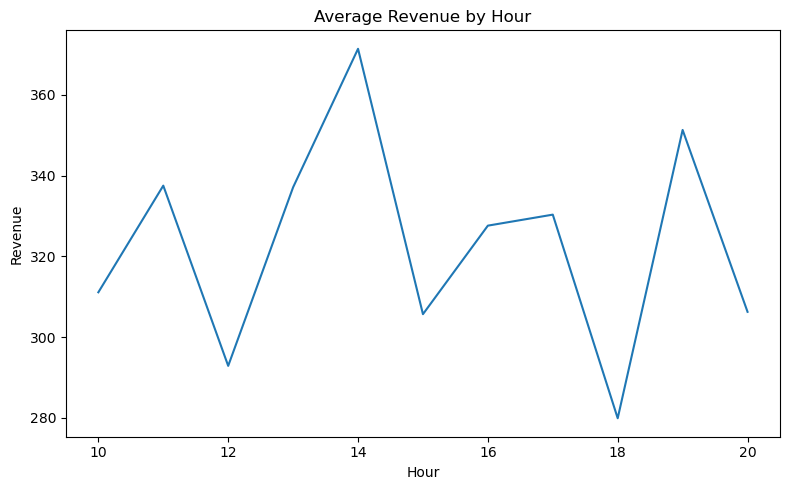

In [16]:
sales_by_hour = df.groupby("hour")["sales"].mean()

plt.figure(figsize=(8,5))
sales_by_hour.plot()
plt.title("Average Revenue by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

### Insight:
    The highest average revenue per transaction occurs at 14:00, followed by 19:00, indicating strong late-afternoon demand. This suggests staffing and promotional focus should be optimized during peak afternoon hours.

#### 7.3 Revenue vs Quantity

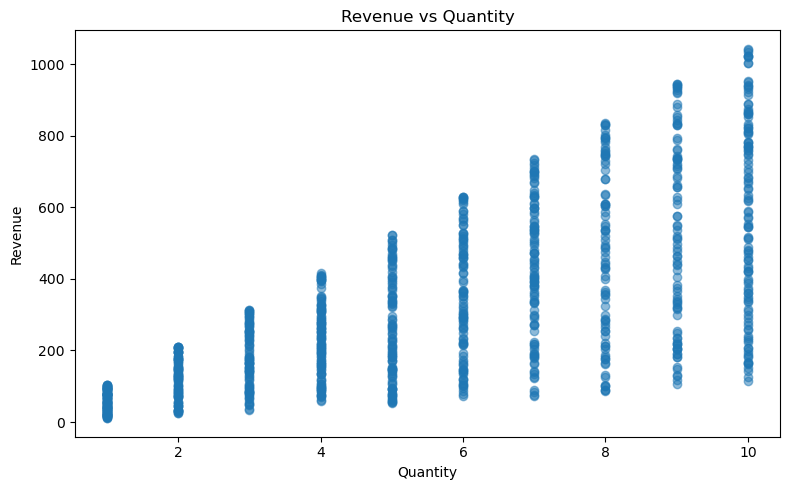

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(df["quantity"], df["sales"], alpha=0.5)
plt.title("Revenue vs Quantity")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

### Observation:
    A clear positive linear relationship is visible between quantity purchased and transaction revenue, reinforcing that revenue is primarily volume-driven.

## 8. Customer Behavior Analysis

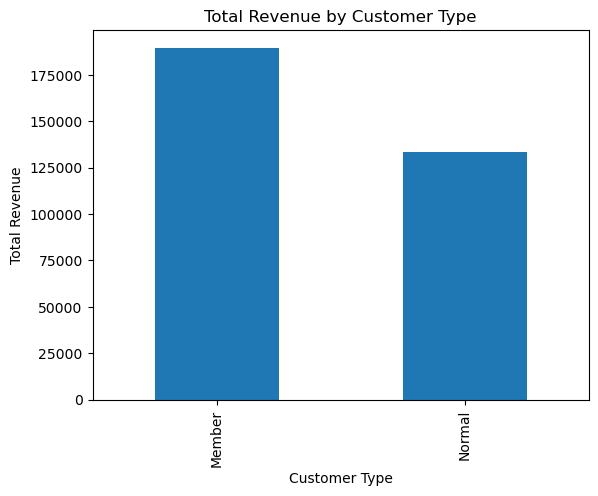

,total_revenue,avg_spend,transactions
customer_type,,,
Member,189694.764,335.742945,565
Normal,133271.985,306.372379,435


In [18]:
customer_behavior = (
    df.groupby("customer_type")["sales"]
      .agg(total_revenue="sum",
           avg_spend="mean",
           transactions="count")
)
customer_behavior["total_revenue"].plot(kind="bar")
plt.title("Total Revenue by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Total Revenue")
plt.show()
customer_behavior

### Insight:
    Member customers generate higher total revenue and higher average spending per transaction, demonstrating the effectiveness of the membership program.

## 9. Correlation Analysis

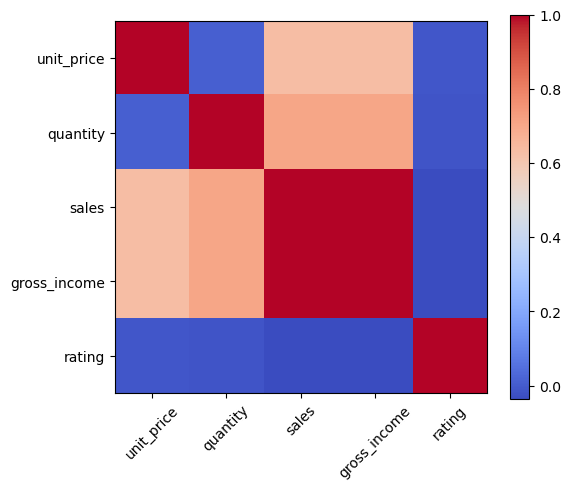

,unit_price,quantity,sales,gross_income,rating
unit_price,1.000000,0.010778,0.633962,0.633962,-0.008778
quantity,0.010778,1.000000,0.705510,0.705510,-0.015815
sales,0.633962,0.705510,1.000000,1.000000,-0.036442
gross_income,0.633962,0.705510,1.000000,1.000000,-0.036442
rating,-0.008778,-0.015815,-0.036442,-0.036442,1.000000


In [19]:
corr = df[["unit_price","quantity","sales","gross_income","rating"]].corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

corr

### Interpretation:
- Quantity has a strong positive correlation with revenue (0.70).
- Unit price shows moderate correlation (0.63).
- Customer ratings have negligible correlation with spending behavior.
- Gross income scales proportionally with revenue due to fixed margins.

## 10. Executive Summary

    Revenue performance is primarily volume-driven, as transaction quantity exhibits the strongest relationship with sales. Member customers generate higher transaction value, reinforcing the strategic importance of loyalty programs. Peak demand occurs during afternoon hours, presenting clear opportunities for operational optimization and targeted promotions.

## 11. Business Recommendations

- Prioritize marketing investment in high-performing product lines.
- Expand membership incentives to increase customer lifetime value.
- Optimize staffing during peak afternoon hours.
- Implement dashboard monitoring for continuous performance tracking.

## 12. Limitations

- Dataset covers only three months, limiting seasonal analysis.
- No marketing campaign or discount data included.
- Analysis is descriptive and does not include predictive modeling.